<a href="https://colab.research.google.com/github/AldhaMufidha/Data-Mining-Pertemuan-1-Aldha-153-/blob/main/UTS_Aldha_Mufidha_Prakoso_153.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif

# Model
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [26]:
from google.colab import files
uploaded = files.upload()

train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

train.head()

Saving data_testing.csv to data_testing (3).csv
Saving data_training.csv to data_training (3).csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [7]:
train.info()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Berdasarkan hasil eksplorasi data, dataset terdiri dari 857 data dengan 13 variabel. Dari total variabel tersebut, 11 variabel merupakan fitur numerik bertipe float yang merepresentasikan karakteristik kimia anggur, sedangkan 2 variabel bertipe integer yaitu quality sebagai target dan Id sebagai identifier data.

Hasil pengecekan missing value menunjukkan bahwa tidak terdapat nilai yang hilang pada dataset, sehingga tidak diperlukan proses imputasi data. Dataset dalam kondisi bersih dan siap untuk digunakan dalam tahap pemodelan.

In [28]:
# cek duplikat
train.duplicated().sum()

np.int64(0)

Tidak ada data ganda

EXploratory Data Analysis (EDA)

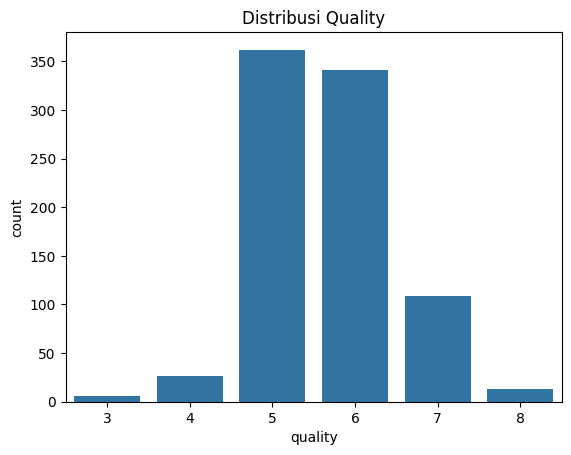

In [31]:
sns.countplot(x='quality', data=train)
plt.title("Distribusi Quality")
plt.show()

Melihat keseimbangan kelas

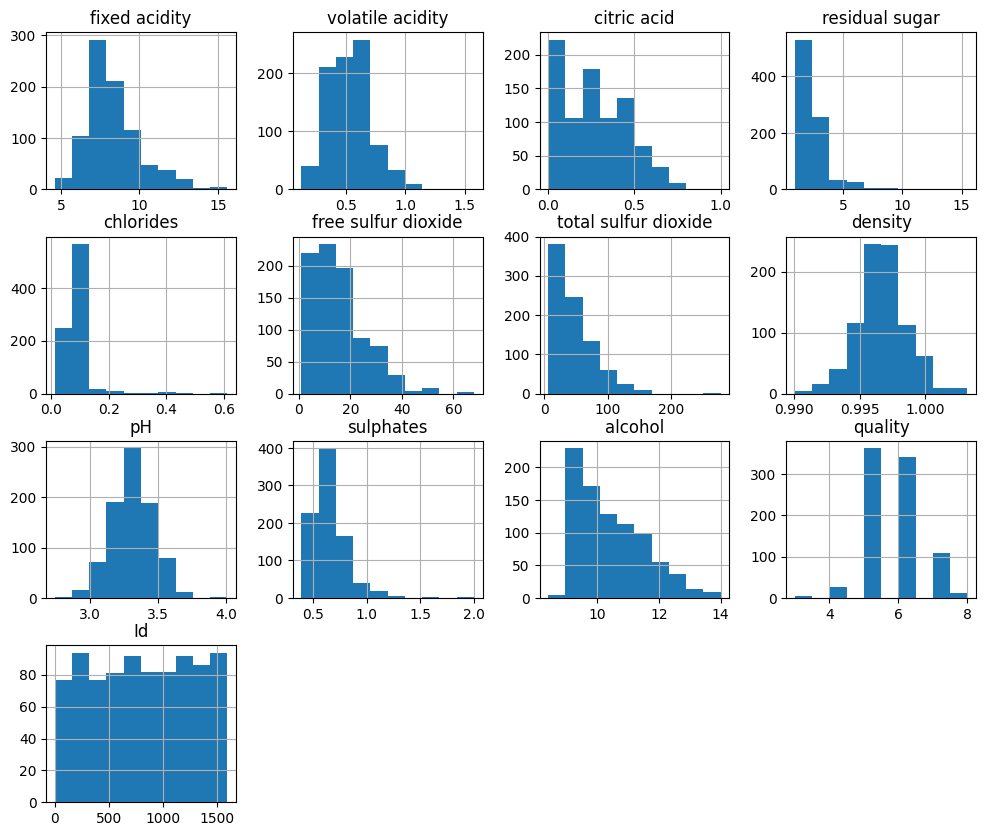

In [32]:
train.hist(figsize=(12,10))
plt.show()

Melihat distribusi tiap fitur

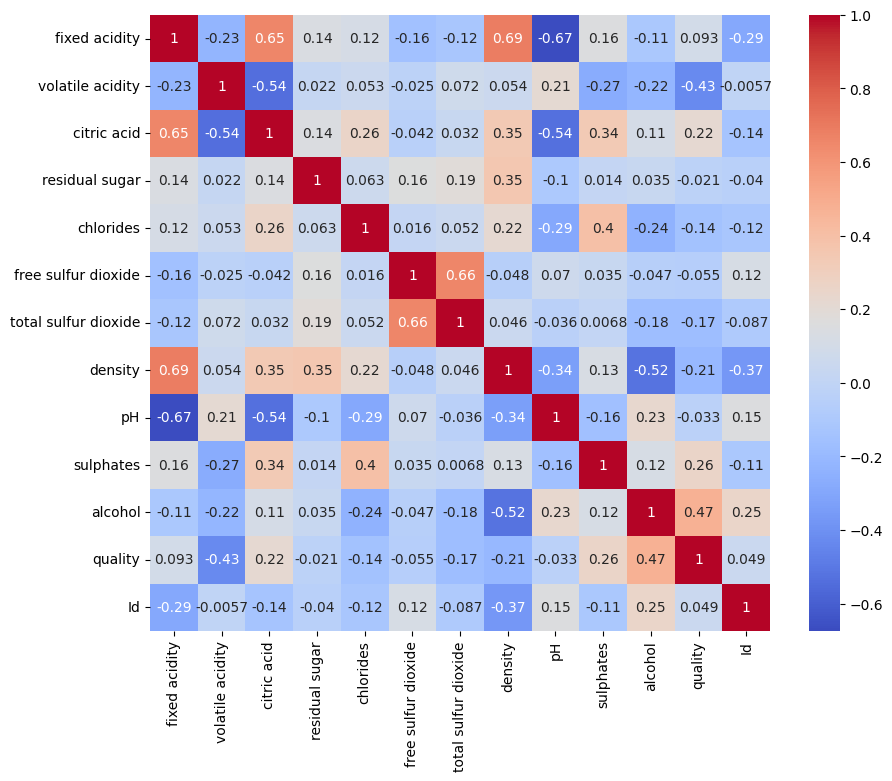

In [33]:
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')
plt.show()

Melihat hubungan antar fitur

Outlier Detection

Boxplot

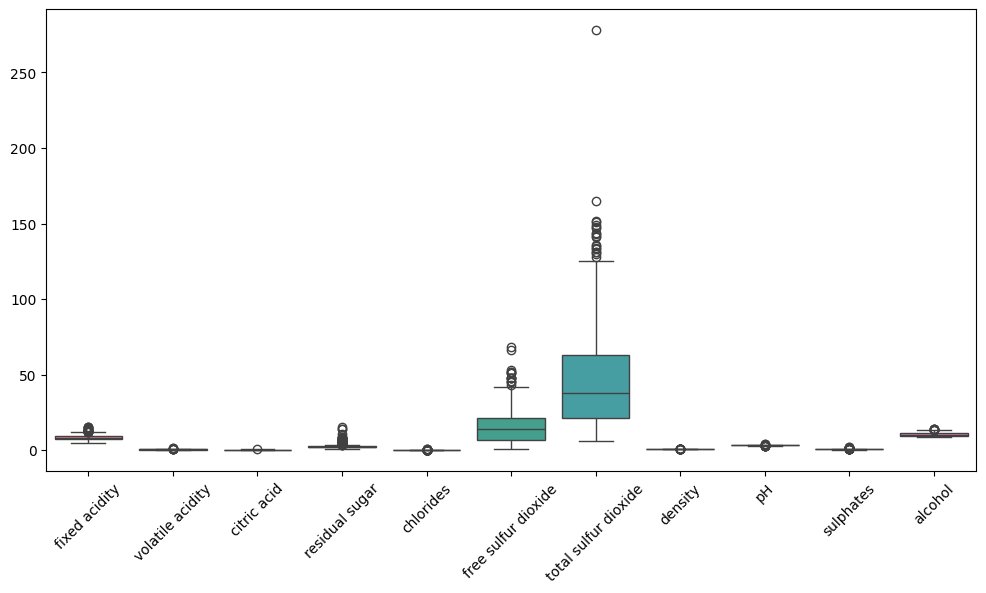

In [34]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train.drop(['quality','Id'], axis=1))
plt.xticks(rotation=45)
plt.show()

Boxplot digunakan untuk melihat distribusi data dan mendeteksi adanya outlier. Berdasarkan visualisasi, terdapat beberapa fitur yang memiliki banyak outlier seperti total sulfur dioxide dan residual sugar. Hal ini menunjukkan adanya nilai ekstrem yang dapat mempengaruhi performa model. Selain itu, beberapa fitur memiliki rentang nilai yang berbeda jauh sehingga diperlukan normalisasi data sebelum proses modelling.

IQR Method

In [35]:
X = train.drop(['quality','Id'], axis=1)
y = train['quality']

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

X_clean = X[~((X < (Q1 - 1.5*IQR)) | (X > (Q3 + 1.5*IQR))).any(axis=1)]
y_clean = y[X_clean.index]

Outlier dihapus secara terkontrol

Normalisasi

Min Max

In [49]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_clean)
pd.DataFrame(X_scaled, columns=X_clean.columns).head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.318841,0.700565,0.109589,0.208333,0.679487,0.219512,0.327731,0.404545,0.405405,0.189655,0.239130
1,0.434783,0.514124,0.301370,0.375000,0.461538,0.268293,0.495798,0.511364,0.472973,0.206897,0.108696
2,0.724638,0.350282,0.547945,0.583333,0.653846,0.292683,0.386555,0.697727,0.378378,0.431034,0.282609
3,0.478261,0.271186,0.438356,0.416667,0.512821,0.756098,0.613445,0.477273,0.486486,0.568966,0.500000
4,0.652174,0.542373,0.684932,0.458333,0.487179,0.658537,0.546218,0.852273,0.756757,0.310345,0.217391


Z Score

In [44]:
z_scaler = StandardScaler()
X_z = z_scaler.fit_transform(X_clean)
pd.DataFrame(X_z, columns=X_clean.columns).head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.559153,1.276755,-0.903535,-1.125100,1.089852,-0.571088,0.077387,-0.485590,-0.655533,-1.156682,-0.574232
1,0.014880,0.281417,-0.116192,-0.205815,-0.086295,-0.343701,0.830440,0.099240,-0.282303,-1.068868,-1.183923
2,1.449961,-0.593274,0.896106,0.943291,0.951482,-0.230007,0.340956,1.119581,-0.804826,0.072706,-0.371002
3,0.230142,-1.015538,0.446196,0.024006,0.190445,1.930172,1.357577,-0.087408,-0.207656,0.775213,0.645150
4,1.091191,0.432226,1.458494,0.253827,0.052075,1.475398,1.056356,1.965717,1.285268,-0.541988,-0.675848


Decimal Scaling

In [45]:
X_decimal = X_clean / (10**np.ceil(np.log10(np.abs(X_clean).max())))
X_decimal.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.073,0.0740,0.08,0.17,0.094,0.10,0.045,0.099576,0.324,0.50,0.098
1,0.081,0.0575,0.22,0.21,0.077,0.12,0.065,0.099670,0.329,0.51,0.092
2,0.101,0.0430,0.40,0.26,0.092,0.13,0.052,0.099834,0.322,0.64,0.100
4,0.084,0.0360,0.32,0.22,0.081,0.32,0.079,0.099640,0.330,0.72,0.110
5,0.096,0.0600,0.50,0.23,0.079,0.28,0.071,0.099970,0.350,0.57,0.097


In [46]:
pd.DataFrame(X_scaled, columns=X_clean.columns).describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000
mean,0.431777,0.461411,0.329672,0.412314,0.477530,0.342025,0.310460,0.493238,0.524079,0.416759,0.361979
std,0.202133,0.187458,0.243767,0.181440,0.185450,0.214691,0.223353,0.182789,0.181173,0.196492,0.214100
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.297101,0.316384,0.109589,0.291667,0.358974,0.170732,0.134454,0.375000,0.405405,0.275862,0.173913
50%,0.391304,0.451977,0.328767,0.375000,0.474359,0.292683,0.252101,0.495455,0.527027,0.379310,0.304348
75%,0.550725,0.581921,0.520548,0.541667,0.576923,0.439024,0.436975,0.597727,0.635135,0.534483,0.500000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


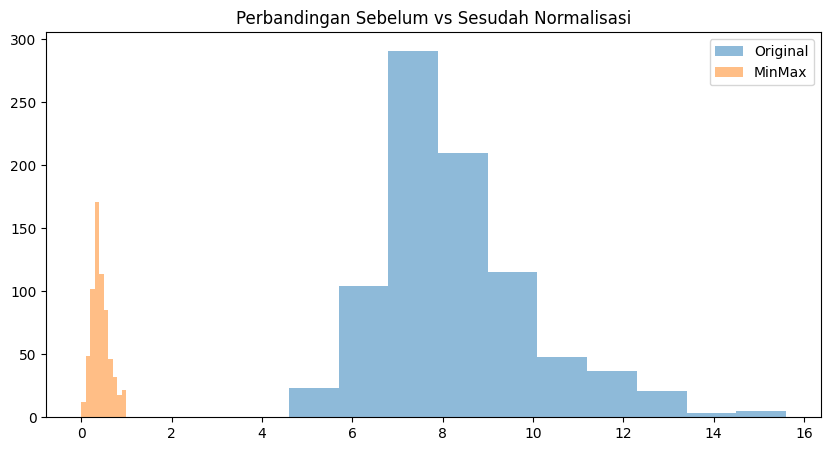

In [55]:
plt.figure(figsize=(10,5))

plt.hist(X.iloc[:,0], alpha=0.5, label='Original')
plt.hist(X_scaled[:,0], alpha=0.5, label='MinMax')

plt.legend()
plt.title("Perbandingan Sebelum vs Sesudah Normalisasi")
plt.show()

Visualisasi histogram menunjukkan perbandingan distribusi data sebelum dan sesudah normalisasi menggunakan metode Min-Max. Setelah normalisasi, nilai data berada dalam rentang 0 hingga 1 tanpa mengubah pola distribusi aslinya.

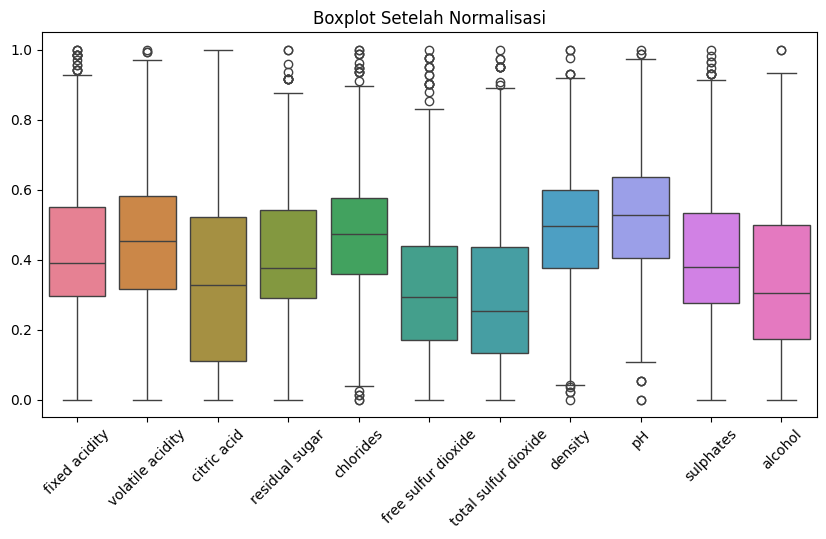

In [54]:
plt.figure(figsize=(10,5))

sns.boxplot(data=pd.DataFrame(X_scaled, columns=X.columns))
plt.title("Boxplot Setelah Normalisasi")
plt.xticks(rotation=45)
plt.show()

Boxplot setelah normalisasi menunjukkan bahwa seluruh fitur telah berada pada rentang 0 hingga 1. Hal ini menandakan bahwa proses normalisasi menggunakan metode Min-Max berhasil dilakukan. Meskipun demikian, masih terdapat beberapa outlier yang terlihat pada beberapa fitur, yang menunjukkan bahwa normalisasi tidak menghilangkan nilai ekstrem, melainkan hanya mengubah skala data.

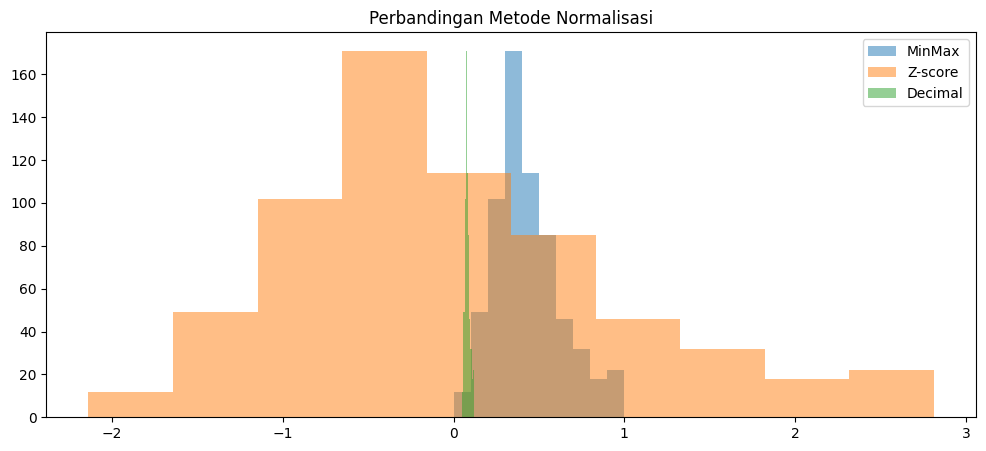

In [52]:
# Perbandingan Tiga Metode Normalisasi
plt.figure(figsize=(12,5))

plt.hist(X_scaled[:,0], alpha=0.5, label='MinMax')
plt.hist(X_z[:,0], alpha=0.5, label='Z-score')
plt.hist(X_decimal.iloc[:,0], alpha=0.5, label='Decimal')

plt.legend()
plt.title("Perbandingan Metode Normalisasi")
plt.show()

Normalisasi tidak menghasilkan output berupa nilai evaluasi, melainkan mengubah skala data. Hasil normalisasi dapat diamati melalui distribusi data yang berubah. Pada metode Min-Max, data berada pada rentang 0 hingga 1, sedangkan pada Z-score data memiliki rata-rata mendekati 0 dan standar deviasi 1. Berdasarkan visualisasi, metode Min-Max dipilih karena menghasilkan distribusi yang lebih stabil untuk pemodelan.

In [58]:
# Data Cube & Pivot
pivot = train.pivot_table(
    values=['alcohol','pH','density'],
    index='quality',
    aggfunc='mean'
)
pivot

,alcohol,density,pH
quality,,,
3,9.691667,0.997682,3.361667
4,10.307692,0.996697,3.382308
5,9.905249,0.997084,3.301409
6,10.634262,0.996563,3.326481
7,11.445566,0.995858,3.298899
8,11.776923,0.995655,3.245385


Berdasarkan hasil pivot table, terlihat bahwa terdapat hubungan antara beberapa fitur kimia dengan kualitas anggur. Nilai alkohol menunjukkan tren meningkat seiring dengan meningkatnya kualitas anggur, yang mengindikasikan bahwa kadar alkohol merupakan faktor penting dalam menentukan kualitas. Sebaliknya, nilai density cenderung menurun pada kualitas yang lebih tinggi. Sementara itu, nilai pH tidak menunjukkan pola yang signifikan terhadap kualitas anggur.

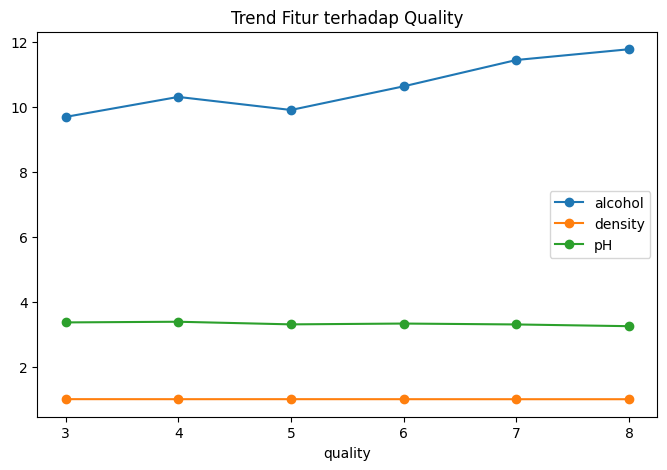

In [60]:
pivot.plot(kind='line', marker='o', figsize=(8,5))
plt.title("Trend Fitur terhadap Quality")
plt.show()

Visualisasi line plot menunjukkan hubungan antara fitur kimia dengan kualitas anggur. Terlihat bahwa nilai alkohol meningkat secara konsisten seiring dengan peningkatan kualitas, sehingga dapat disimpulkan bahwa alkohol memiliki hubungan positif dengan kualitas anggur. Sebaliknya, density menunjukkan tren menurun, yang mengindikasikan hubungan negatif dengan kualitas. Sementara itu, pH tidak menunjukkan pola yang konsisten sehingga pengaruhnya terhadap kualitas relatif kecil.

Standarisasi

In [63]:
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_clean)

PCA

In [64]:
pca = PCA()
X_pca = pca.fit_transform(X_std)

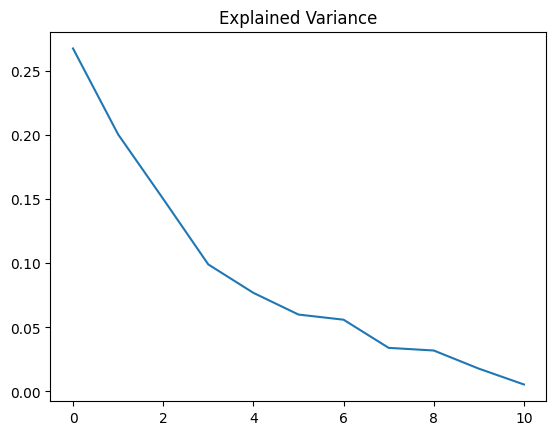

In [65]:
plt.plot(pca.explained_variance_ratio_)
plt.title("Explained Variance")
plt.show()

Berdasarkan grafik explained variance, komponen pertama (PC1) memiliki kontribusi terbesar dalam menjelaskan variasi data, diikuti oleh PC2 dan seterusnya. Terlihat bahwa kontribusi variance menurun secara signifikan setelah beberapa komponen awal, sehingga sebagian besar informasi data sudah dapat direpresentasikan oleh beberapa komponen utama saja.

In [66]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

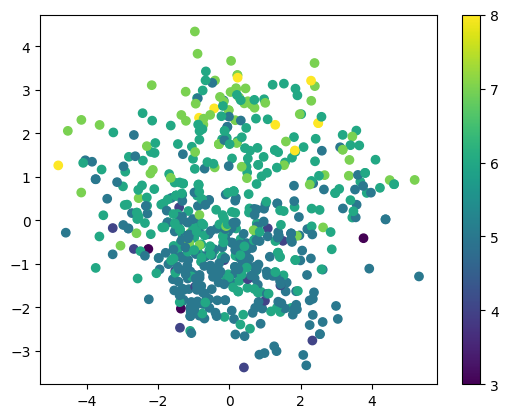

In [67]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_clean)
plt.colorbar()
plt.show()

Visualisasi PCA menunjukkan bahwa data tidak membentuk cluster yang terpisah secara jelas berdasarkan nilai quality. Hal ini mengindikasikan bahwa pemisahan kelas tidak linear dan cukup kompleks. Meskipun terdapat sedikit kecenderungan distribusi, namun masih terdapat overlap antar kelas sehingga model klasifikasi diperlukan untuk memprediksi kualitas secara lebih akurat.

Feature Selection

In [68]:
corr = train.corr()['quality'].sort_values(ascending=False)
corr

,quality
quality,1.000000
alcohol,0.473555
sulphates,0.260703
citric acid,0.221263
fixed acidity,0.092714
Id,0.049030
residual sugar,-0.020511
pH,-0.033199
free sulfur dioxide,-0.054509
chlorides,-0.144946


ANOVA

In [70]:
from sklearn.feature_selection import f_classif

f_values, p_values = f_classif(X_clean, y_clean)

anova_results = pd.DataFrame({
    'Feature': X_clean.columns,
    'F-value': f_values,
    'p-value': p_values
})

anova_results.sort_values(by='F-value', ascending=False)

,Feature,F-value,p-value
10,alcohol,47.007407,1.856084e-41
9,sulphates,29.124010,1.088508e-26
1,volatile acidity,22.005949,2.179440e-20
2,citric acid,9.619545,7.197418e-09
6,total sulfur dioxide,8.503919,8.267549e-08
7,density,8.007921,2.446561e-07
4,chlorides,6.675674,4.479801e-06
8,pH,2.075219,6.672528e-02
0,fixed acidity,1.667249,1.403555e-01
5,free sulfur dioxide,1.232642,2.920651e-01


Berdasarkan uji ANOVA, fitur alcohol memiliki nilai F tertinggi dan p-value yang sangat kecil, sehingga merupakan faktor paling berpengaruh terhadap kualitas anggur. Selain itu, sulphates dan volatile acidity juga menunjukkan pengaruh yang signifikan.

Sementara itu, beberapa fitur seperti residual sugar, free sulfur dioxide, dan fixed acidity memiliki p-value yang besar, sehingga tidak berpengaruh signifikan terhadap kualitas anggur. Oleh karena itu, fitur-fitur tersebut dapat dipertimbangkan untuk tidak digunakan dalam pemodelan.

Modelling

Split

In [71]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_clean, test_size=0.2, random_state=42
)

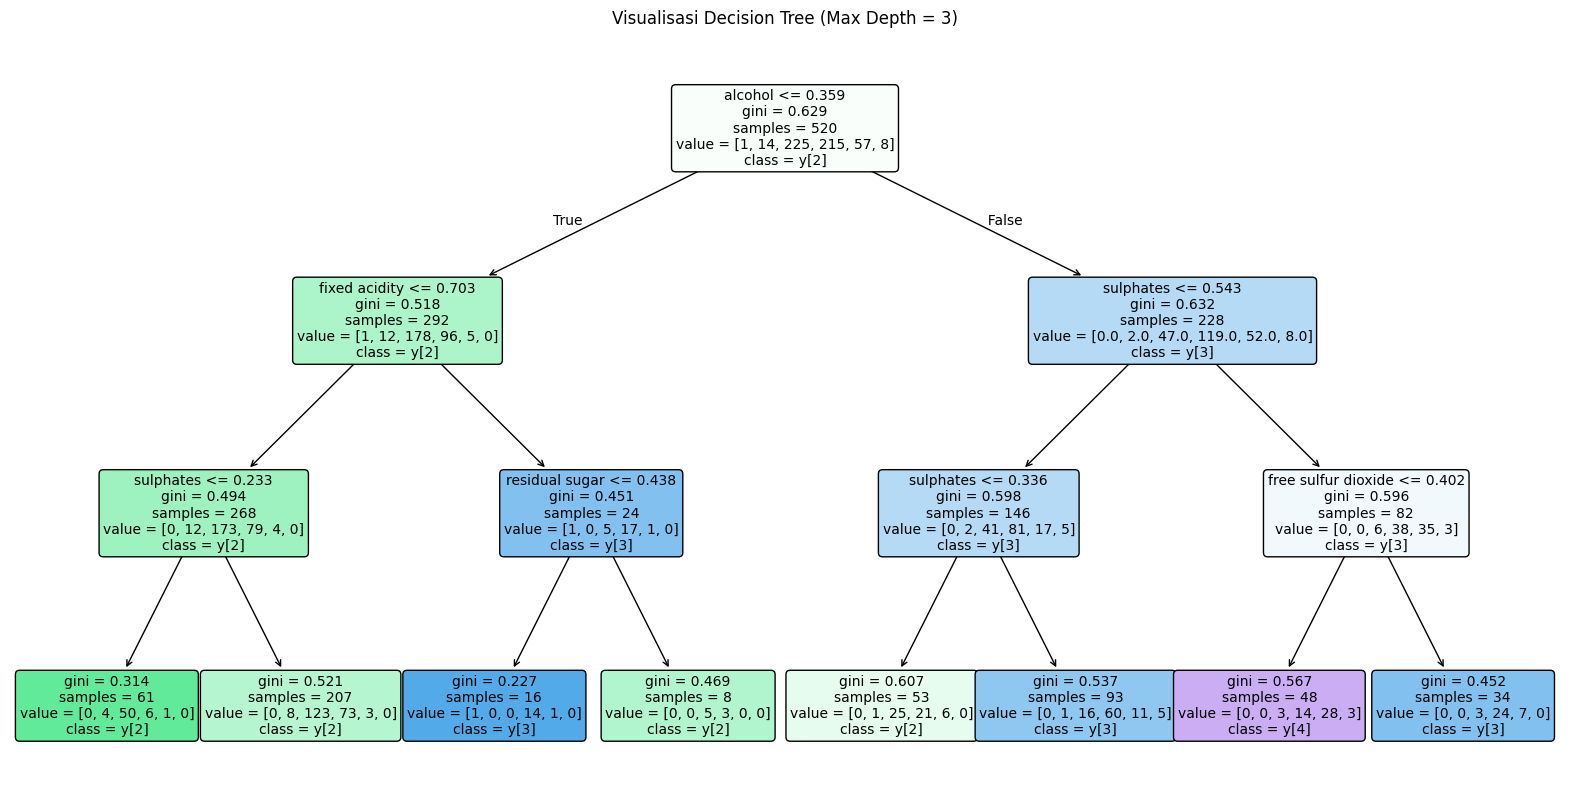

In [77]:
# Training Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt.predict(X_val)

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    filled=True,
    feature_names=X.columns,
    class_names=True,
    rounded=True,
    fontsize=10
)

plt.title("Visualisasi Decision Tree (Max Depth = 3)")

# Simpan dulu
plt.savefig("decision_tree.png", dpi=300, bbox_inches='tight')

# Baru tampilkan
plt.show()

Visualisasi Decision Tree dilakukan dengan membatasi kedalaman pohon (max_depth=3) agar struktur model lebih sederhana dan mudah dipahami. Setiap node pada pohon menunjukkan aturan pemisahan berdasarkan nilai fitur tertentu. Fitur yang muncul pada bagian atas pohon, seperti alcohol, menunjukkan bahwa fitur tersebut memiliki pengaruh besar dalam menentukan kualitas anggur. Semakin ke bawah, pembagian menjadi lebih spesifik untuk meningkatkan akurasi klasifikasi.

In [93]:
# Accuracy Decision Tree
acc_dt = accuracy_score(y_val, y_pred_dt)
print("Accuracy Decision Tree:", acc_dt)

Accuracy Decision Tree: 0.48091603053435117


KNN

In [87]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_val)
acc_knn = accuracy_score(y_val, y_pred_knn)

print("Accuracy KNN:", acc_knn)


Accuracy KNN: 0.5877862595419847


Naive Bayes

In [88]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_val)
acc_nb = accuracy_score(y_val, y_pred_nb)

print("Accuracy Naive Bayes:", acc_nb)

Accuracy Naive Bayes: 0.4580152671755725


Random Forest

In [89]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)

print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.42748091603053434


Logistic Regression

In [90]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)
acc_lr = accuracy_score(y_val, y_pred_lr)

print("Accuracy Logistic Regression:", acc_lr)

Accuracy Logistic Regression: 0.48091603053435117


Heatmap Semua Model

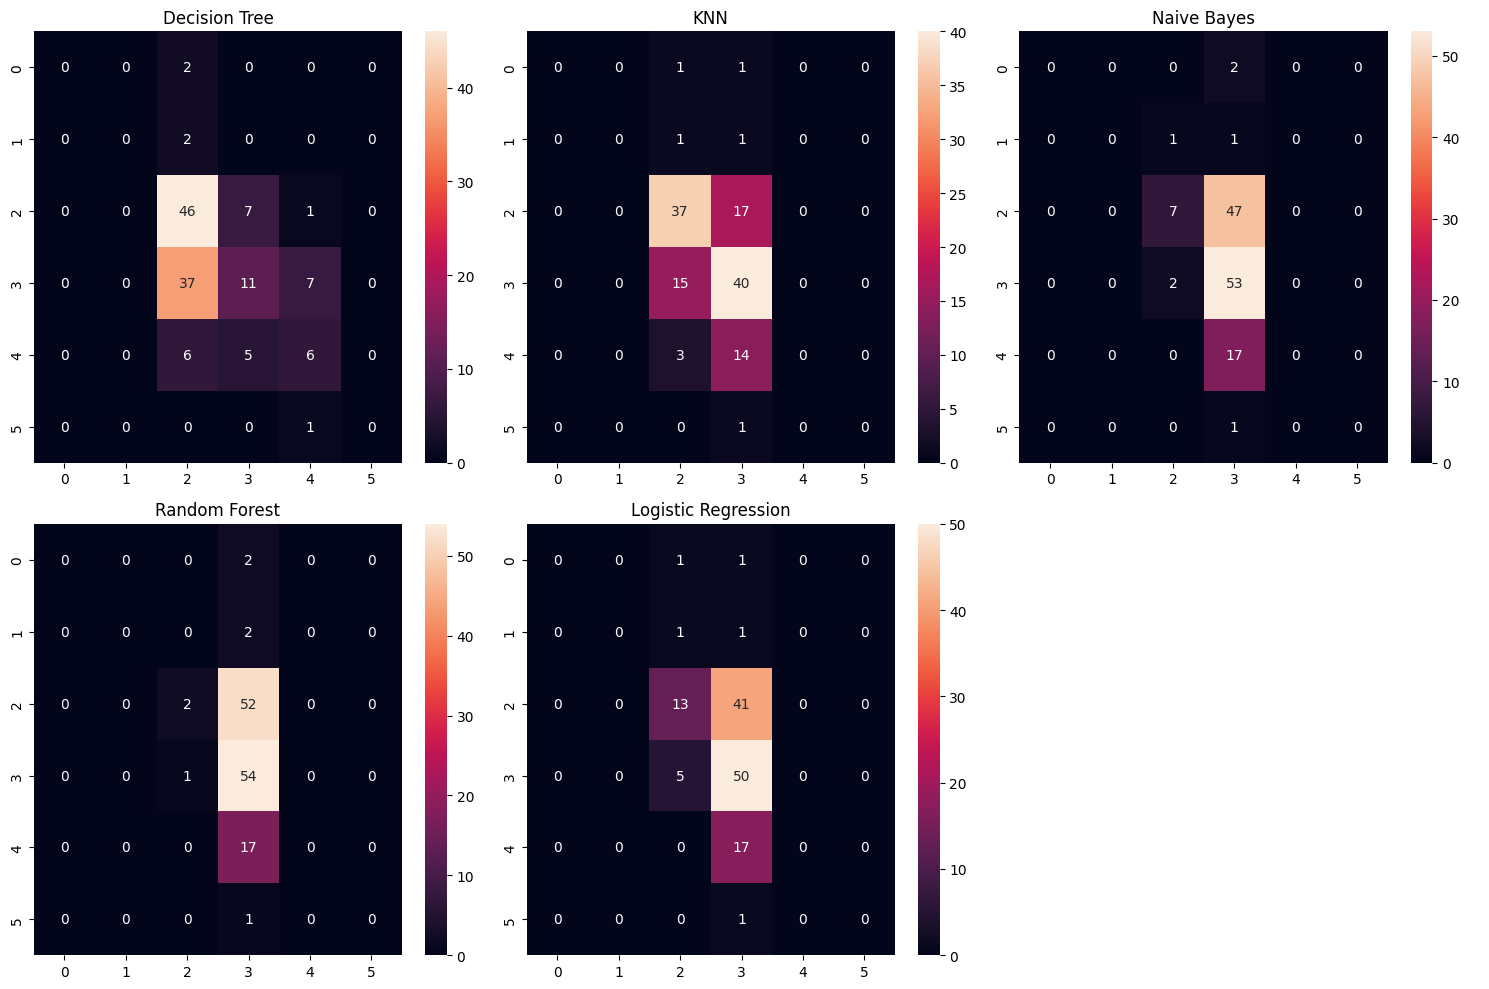

In [91]:
# Confusion matrix masing-masing
cm_dt = confusion_matrix(y_val, y_pred_dt)
cm_knn = confusion_matrix(y_val, y_pred_knn)
cm_nb = confusion_matrix(y_val, y_pred_nb)
cm_rf = confusion_matrix(y_val, y_pred_rf)
cm_lr = confusion_matrix(y_val, y_pred_lr)

fig, axes = plt.subplots(2, 3, figsize=(15,10))

sns.heatmap(cm_dt, annot=True, fmt='d', ax=axes[0,0])
axes[0,0].set_title("Decision Tree")

sns.heatmap(cm_knn, annot=True, fmt='d', ax=axes[0,1])
axes[0,1].set_title("KNN")

sns.heatmap(cm_nb, annot=True, fmt='d', ax=axes[0,2])
axes[0,2].set_title("Naive Bayes")

sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1,0])
axes[1,0].set_title("Random Forest")

sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[1,1])
axes[1,1].set_title("Logistic Regression")

# kosongkan 1 plot
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

Confusion matrix digunakan untuk mengevaluasi performa model klasifikasi dengan membandingkan nilai aktual dan prediksi. Nilai pada diagonal utama menunjukkan jumlah prediksi yang benar. Berdasarkan hasil visualisasi, sebagian besar model mampu memprediksi dengan baik pada kelas mayoritas (quality 5 dan 6), namun mengalami kesulitan pada kelas minoritas. Hal ini menunjukkan adanya ketidakseimbangan data yang mempengaruhi performa model.

Perbandingan Accuracy

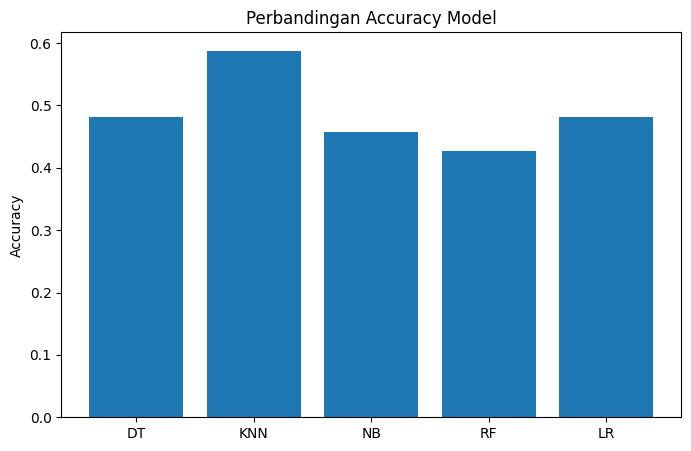

  Model  Accuracy
0    DT  0.480916
1   KNN  0.587786
2    NB  0.458015
3    RF  0.427481
4    LR  0.480916


In [94]:
model_names = ['DT', 'KNN', 'NB', 'RF', 'LR']
accuracies = [acc_dt, acc_knn, acc_nb, acc_rf, acc_lr]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.title("Perbandingan Accuracy Model")
plt.ylabel("Accuracy")
plt.show()

# tampilkan juga tabel
acc_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})
print(acc_df)

In [95]:
best_model_name = acc_df.sort_values(by='Accuracy', ascending=False).iloc[0]['Model']
print("Model terbaik:", best_model_name)

Model terbaik: KNN


In [98]:
# preprocessing test
X_test_final = test.drop(['Id'], axis=1)
X_test_final = scaler.transform(X_test_final)  # pakai MinMaxScaler kamu

# pilih model terbaik
if best_model_name == 'DT':
    final_model = dt
elif best_model_name == 'KNN':
    final_model = knn
elif best_model_name == 'NB':
    final_model = nb
elif best_model_name == 'RF':
    final_model = rf
else:
    final_model = lr

# prediksi
test_pred = final_model.predict(X_test_final)

# buat CSV
submission = pd.DataFrame({
    'Id': test['Id'],
    'quality': test_pred
})

submission.to_csv('submission.csv', index=False)

print("CSV berhasil dibuat!")

CSV berhasil dibuat!


In [99]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>